**Análise Exploratória da base de dados**

Usamos os dados do dataset obtido do Mendeley Data: https://data.mendeley.com/datasets/pcx7mj68yn/4


Base analisada: **Enquadrado e Centralizado - Versão 4 - Método B**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Instalação de Dependências


In [2]:
!pip install -q tensorflow scikit-learn matplotlib seaborn pandas numpy pillow

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from tensorflow.keras.applications import (
    VGG16, VGG19, ResNet50, InceptionV3, MobileNetV2
)
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from PIL import Image
import os
import time
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


# Montar o Drive
Identificação das classes, contagem de imagens por classe e visualização da distribuição do dataset de cacau.

Etapa 01 - Análise exploratória da base de imagens.

In [4]:
from google.colab import drive
drive.mount("/content/drive")
print("Drive montado!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive montado!


# Definir Dataset

In [5]:
DATASET_DIR = "/content/drive/MyDrive/Dataset Cocoa Beans/Enquadrado e Centralizado - Versão 4 - Método B"
dataset_path = DATASET_DIR
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Caminho não encontrado: {dataset_path}")
print(f"Dataset: {dataset_path}")

Dataset: /content/drive/MyDrive/Dataset Cocoa Beans/Enquadrado e Centralizado - Versão 4 - Método B


In [6]:
classes = sorted([d for d in os.listdir(dataset_path)
                  if os.path.isdir(os.path.join(dataset_path, d))])
print(f"\n{'='*60}")
print(f"CLASSES ENCONTRADAS NO DATASET")
print(f"{'='*60}")
for i, cls in enumerate(classes, 1):
    print(f"{i}. {cls}")
print(f"{'='*60}")
print(f"Total de classes: {len(classes)}")


CLASSES ENCONTRADAS NO DATASET
1. Agglutinated
2. Brittle
3. Compartmentalized_Brown
4. Compartmentalized_PartiallyPurple
5. Compartmentalized_Purple
6. Compartmentalized_Slaty
7. Compartmentalized_White
8. Flattened
9. Moldered
10. Plated_Brown
11. Plated_PartiallyPurple
12. Plated_Purple
13. Plated_Slaty
14. Plated_White
Total de classes: 14


In [7]:
print("\nContando imagens por classe...\n")

class_counts = {}
all_images = []

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    class_counts[cls] = len(images)

    for img in images:
        all_images.append({
            'class': cls,
            'path': os.path.join(class_path, img),
            'filename': img
        })

df = pd.DataFrame(all_images)

print(f"{'='*60}")
print(f"DISTRIBUIÇÃO DE IMAGENS POR CLASSE")
print(f"{'='*60}")
for cls, count in sorted(class_counts.items()):
    print(f"{cls:30s}: {count:4d} imagens ({count/len(df)*100:5.2f}%)")
print(f"{'='*60}")
print(f"TOTAL DE IMAGENS: {len(df)}")
print(f"{'='*60}")


Contando imagens por classe...

DISTRIBUIÇÃO DE IMAGENS POR CLASSE
Agglutinated                  :  100 imagens ( 7.14%)
Brittle                       :  100 imagens ( 7.14%)
Compartmentalized_Brown       :  100 imagens ( 7.14%)
Compartmentalized_PartiallyPurple:  100 imagens ( 7.14%)
Compartmentalized_Purple      :  100 imagens ( 7.14%)
Compartmentalized_Slaty       :  100 imagens ( 7.14%)
Compartmentalized_White       :  100 imagens ( 7.14%)
Flattened                     :  100 imagens ( 7.14%)
Moldered                      :  100 imagens ( 7.14%)
Plated_Brown                  :  100 imagens ( 7.14%)
Plated_PartiallyPurple        :  100 imagens ( 7.14%)
Plated_Purple                 :  100 imagens ( 7.14%)
Plated_Slaty                  :  100 imagens ( 7.14%)
Plated_White                  :  100 imagens ( 7.14%)
TOTAL DE IMAGENS: 1400


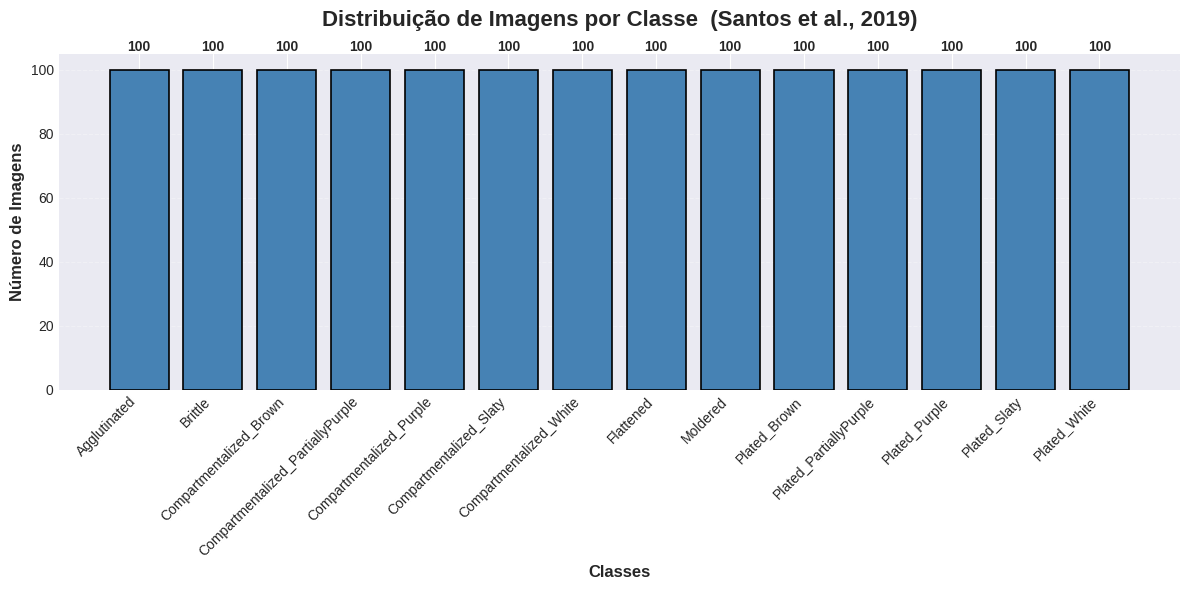

Gráfico salvo: distribuicao_classes.png


In [8]:
plt.figure(figsize=(12, 6))
class_distribution = df['class'].value_counts().sort_index()
bars = plt.bar(range(len(class_distribution)), class_distribution.values,
               color='steelblue', edgecolor='black', linewidth=1.2)

for i, (bar, value) in enumerate(zip(bars, class_distribution.values)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(value), ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.title('Distribuição de Imagens por Classe  (Santos et al., 2019)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Classes', fontsize=12, fontweight='bold')
plt.ylabel('Número de Imagens', fontsize=12, fontweight='bold')
plt.xticks(range(len(class_distribution)), class_distribution.index,
           rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('distribuicao_classes.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico salvo: distribuicao_classes.png")

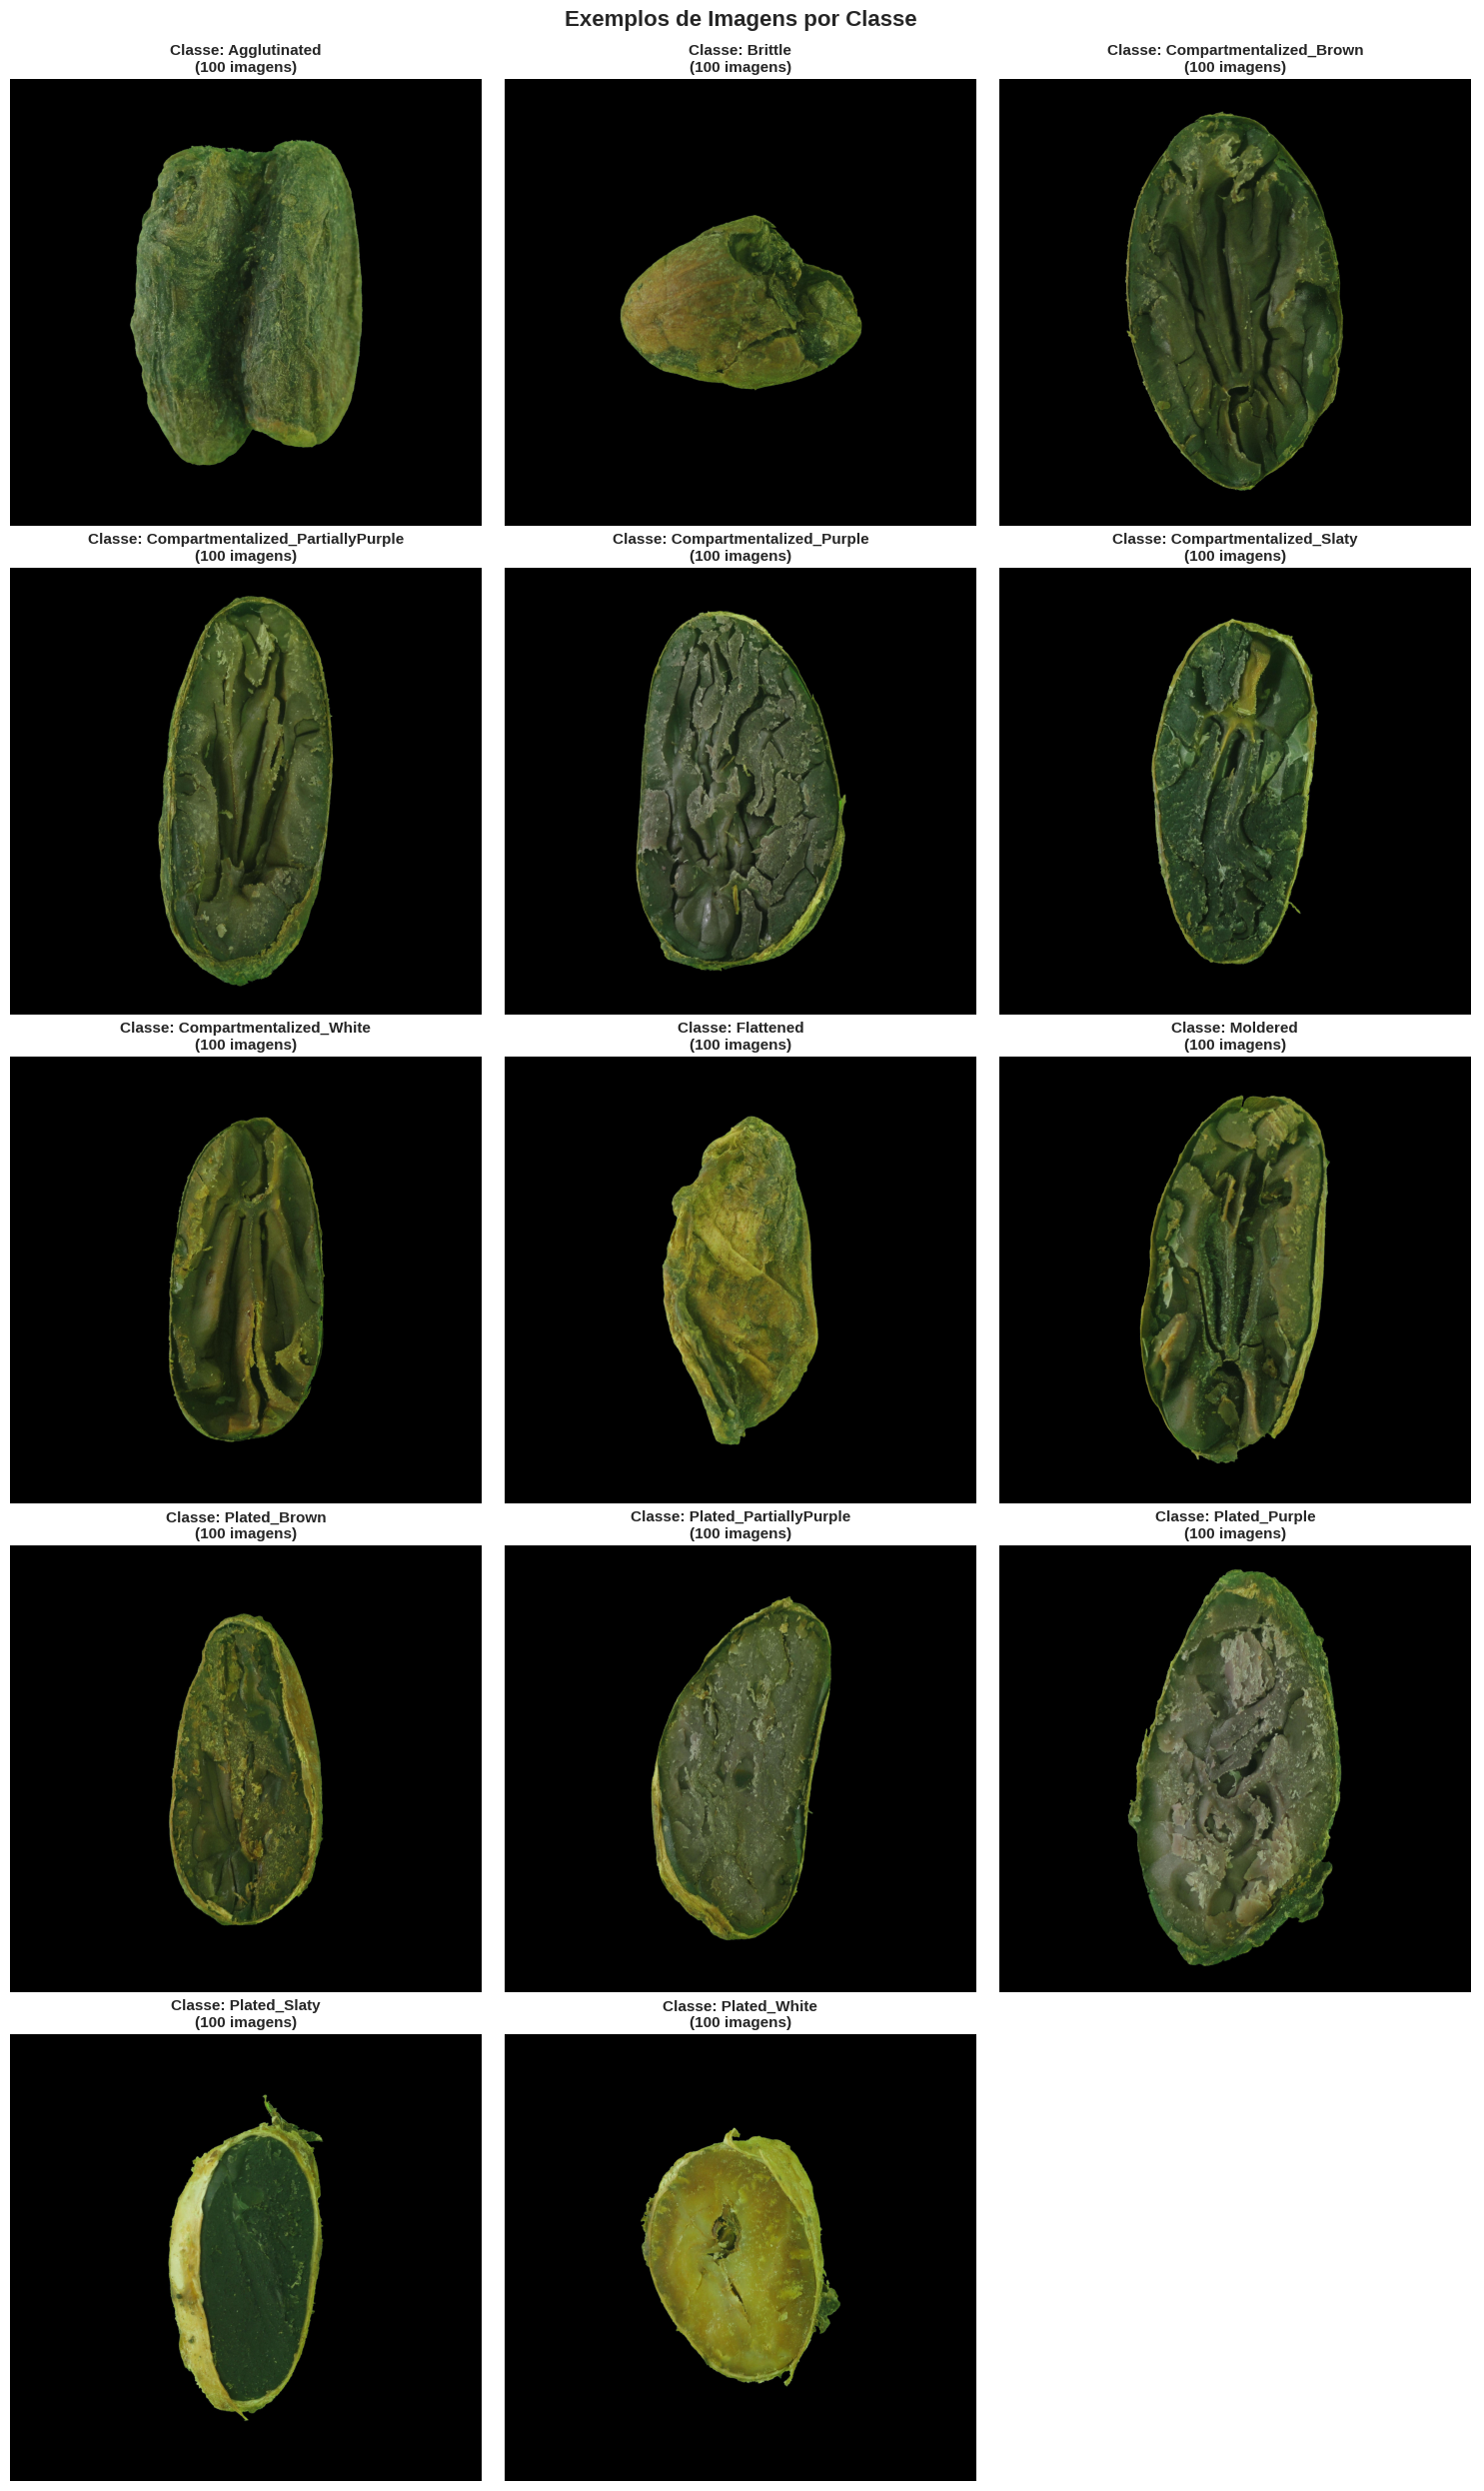

Exemplos salvos: exemplos_classes.png


In [9]:
n_classes = len(classes)
n_cols = 3
n_rows = (n_classes + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.ravel() if n_classes > 1 else [axes]

for idx, cls in enumerate(classes):
    class_path = os.path.join(dataset_path, cls)
    sample_imgs = [f for f in os.listdir(class_path)
                   if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:1]

    if sample_imgs:
        img_path = os.path.join(class_path, sample_imgs[0])
        img = Image.open(img_path)
        axes[idx].imshow(img)
        axes[idx].set_title(f'Classe: {cls}\n({class_counts[cls]} imagens)',
                           fontsize=11, fontweight='bold')
        axes[idx].axis('off')

for idx in range(n_classes, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Exemplos de Imagens por Classe', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('exemplos_classes.png', dpi=300, bbox_inches='tight')
plt.show()

print("Exemplos salvos: exemplos_classes.png")

In [10]:
class_to_idx = {cls: idx for idx, cls in enumerate(sorted(classes))}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}
print("="*60)
print("Mapeamento de Classes:")
print("="*60)
for cls, idx in class_to_idx.items():
    print(f"{idx}: {cls}")
print("="*60)

Mapeamento de Classes:
0: Agglutinated
1: Brittle
2: Compartmentalized_Brown
3: Compartmentalized_PartiallyPurple
4: Compartmentalized_Purple
5: Compartmentalized_Slaty
6: Compartmentalized_White
7: Flattened
8: Moldered
9: Plated_Brown
10: Plated_PartiallyPurple
11: Plated_Purple
12: Plated_Slaty
13: Plated_White


In [11]:
df['label'] = df['class'].map(class_to_idx)

X_paths = df['path'].values
y = df['label'].values

X_train_paths, X_test_paths, y_train, y_test = train_test_split(
    X_paths, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("="*60)
print("Partição Holdout Criada:")
print("="*60)
print(f"Conjunto de Treino: {len(X_train_paths)} imagens ({len(X_train_paths)/len(df)*100:.1f}%)")
print(f"Conjunto de Teste:  {len(X_test_paths)} imagens ({len(X_test_paths)/len(df)*100:.1f}%)")
print("="*60)

print("\nDistribuição no Conjunto de Treino:")
train_dist = pd.Series(y_train).value_counts().sort_index()
for idx, count in train_dist.items():
    print(f"  Classe {idx} ({idx_to_class[idx]:30s}): {count:4d} imagens")
print("="*60)
print("\nDistribuição no Conjunto de Teste:")
test_dist = pd.Series(y_test).value_counts().sort_index()
for idx, count in test_dist.items():
    print(f"  Classe {idx} ({idx_to_class[idx]:30s}): {count:4d} imagens")

Partição Holdout Criada:
Conjunto de Treino: 1120 imagens (80.0%)
Conjunto de Teste:  280 imagens (20.0%)

Distribuição no Conjunto de Treino:
  Classe 0 (Agglutinated                  ):   80 imagens
  Classe 1 (Brittle                       ):   80 imagens
  Classe 2 (Compartmentalized_Brown       ):   80 imagens
  Classe 3 (Compartmentalized_PartiallyPurple):   80 imagens
  Classe 4 (Compartmentalized_Purple      ):   80 imagens
  Classe 5 (Compartmentalized_Slaty       ):   80 imagens
  Classe 6 (Compartmentalized_White       ):   80 imagens
  Classe 7 (Flattened                     ):   80 imagens
  Classe 8 (Moldered                      ):   80 imagens
  Classe 9 (Plated_Brown                  ):   80 imagens
  Classe 10 (Plated_PartiallyPurple        ):   80 imagens
  Classe 11 (Plated_Purple                 ):   80 imagens
  Classe 12 (Plated_Slaty                  ):   80 imagens
  Classe 13 (Plated_White                  ):   80 imagens

Distribuição no Conjunto de Teste:
  

# Carrega e preprocessa uma imagem para entrada em CNN.

In [12]:
def load_and_preprocess_image(img_path, target_size=(224, 224), preprocess_fn=None):

    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    if preprocess_fn is not None:
        img_array = preprocess_fn(img_array)

    return img_array

print("Função de preprocessamento criada!")
print("Preparação de dados concluída!")

Função de preprocessamento criada!
Preparação de dados concluída!


In [13]:
cnn_models = {
    'VGG16': {
        'model': VGG16(weights='imagenet', include_top=False, pooling='avg'),
        'preprocess': vgg_preprocess,
        'input_size': (224, 224),
        'feature_dim': 512
    },
    'VGG19': {
        'model': VGG19(weights='imagenet', include_top=False, pooling='avg'),
        'preprocess': vgg_preprocess,
        'input_size': (224, 224),
        'feature_dim': 512
    },
    'ResNet50': {
        'model': ResNet50(weights='imagenet', include_top=False, pooling='avg'),
        'preprocess': resnet_preprocess,
        'input_size': (224, 224),
        'feature_dim': 2048
    },
    'InceptionV3': {
        'model': InceptionV3(weights='imagenet', include_top=False, pooling='avg'),
        'preprocess': inception_preprocess,
        'input_size': (299, 299),
        'feature_dim': 2048
    },
    'MobileNetV2': {
        'model': MobileNetV2(weights='imagenet', include_top=False, pooling='avg'),
        'preprocess': mobilenet_preprocess,
        'input_size': (224, 224),
        'feature_dim': 1280
    }
}

print("\nArquiteturas CNN Selecionadas:")
print("="*70)
for name, info in cnn_models.items():
    print(f"{name:15s} | Input: {str(info['input_size']):12s} | Features: {info['feature_dim']:4d}")
print("="*70)
print("\nReferência: Malcher and Guedes (2022)")
print("Todos os modelos com pesos ImageNet CONGELADOS (include_top=False)")
print(f"{'='*70}")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Arquiteturas CNN Selecionadas:
VGG16           | Input: (224, 224)   | Features:  512
VGG19           | Input: (224, 224)   | Features:  512
ResNet50        | Input: (224, 224)   | Features: 2048
InceptionV3     | Input: (299, 299)   | Features: 2048
MobileNetV2     | Input: (224, 224)   | Features: 1280

Referência: Malcher and Guedes (2022)
Todos os modelos com pesos ImageNet CONGELADOS (include_top=False)


Extrai características visuais de imagens usando CNN pré-treinada.

    Pipeline:
    1. Carrega imagem e redimensiona
    2. Aplica preprocessamento da CNN
    3. Passa pela CNN sem camadas de classificação
    4. Obtém vetor via Global Average Pooling

In [14]:
def extract_features(image_paths, cnn_name, verbose=True):
    model_info = cnn_models[cnn_name]
    model = model_info['model']
    preprocess_fn = model_info['preprocess']
    input_size = model_info['input_size']

    features_list = []

    if verbose:
        print(f"\nExtraindo características com {cnn_name}...")
        print(f"   Input size: {input_size}")
        print(f"   Feature dimension: {model_info['feature_dim']}")

    for idx, img_path in enumerate(image_paths):
        if verbose and (idx + 1) % 100 == 0:
            print(f"Processadas {idx + 1}/{len(image_paths)} imagens ({(idx+1)/len(image_paths)*100:.1f}%)")

        img_array = load_and_preprocess_image(img_path, input_size, preprocess_fn)
        features = model.predict(img_array, verbose=0)
        features_list.append(features.flatten())

    features_array = np.array(features_list)

    if verbose:
        print(f"Extração concluída! Shape: {features_array.shape}")

    return features_array

print("Função de extração de features criada!")

Função de extração de features criada!


In [15]:
features_dict = {}

print("\n" + "="*70)
print("INICIANDO EXTRAÇÃO DE CARACTERÍSTICAS")
print("="*70)
print("EXTRAÇÃO OTIMIZADA - Estimativa: ~15-20min total")

for cnn_name in cnn_models.keys():
    print(f"\n{'='*70}")
    print(f" CNN: {cnn_name}")
    print(f"{'='*70}")

    start_time = time.time()

    print("\nConjunto de TREINO:")
    X_train_features = extract_features(X_train_paths, cnn_name, verbose=True)

    print("\nConjunto de TESTE:")
    X_test_features = extract_features(X_test_paths, cnn_name, verbose=True)

    features_dict[cnn_name] = {
        'X_train': X_train_features,
        'X_test': X_test_features
    }

    elapsed = time.time() - start_time

    print(f"\n {cnn_name} concluído:")
    print(f"Treino: {X_train_features.shape}")
    print(f"Teste:  {X_test_features.shape}")
    print(f"Tempo: {elapsed/60:.1f}min")

print(f"\n{'='*70}")
print("EXTRAÇÃO DE CARACTERÍSTICAS COMPLETA PARA TODAS AS CNNs!")
print(f"{'='*70}")


INICIANDO EXTRAÇÃO DE CARACTERÍSTICAS
EXTRAÇÃO OTIMIZADA - Estimativa: ~15-20min total

 CNN: VGG16

Conjunto de TREINO:

Extraindo características com VGG16...
   Input size: (224, 224)
   Feature dimension: 512
Processadas 100/1120 imagens (8.9%)
Processadas 200/1120 imagens (17.9%)
Processadas 300/1120 imagens (26.8%)
Processadas 400/1120 imagens (35.7%)
Processadas 500/1120 imagens (44.6%)
Processadas 600/1120 imagens (53.6%)
Processadas 700/1120 imagens (62.5%)
Processadas 800/1120 imagens (71.4%)
Processadas 900/1120 imagens (80.4%)
Processadas 1000/1120 imagens (89.3%)
Processadas 1100/1120 imagens (98.2%)
Extração concluída! Shape: (1120, 512)

Conjunto de TESTE:

Extraindo características com VGG16...
   Input size: (224, 224)
   Feature dimension: 512
Processadas 100/280 imagens (35.7%)
Processadas 200/280 imagens (71.4%)
Extração concluída! Shape: (280, 512)

 VGG16 concluído:
Treino: (1120, 512)
Teste:  (280, 512)
Tempo: 37.7min

 CNN: VGG19

Conjunto de TREINO:

Extraindo

# Grid Search OTIMIZADO para execução viável
# Mantém diversidade mas reduz combinações

In [16]:
param_grid = {
    'C': [0.1, 1, 10],  # 3 valores
    'kernel': ['rbf', 'linear'],  # 2 kernels principais
    'gamma': ['scale', 0.01]  # 2 valores
}

print("\n" + "="*70)
print("GRADE DE HIPERPARÂMETROS PARA SVM - OTIMIZADA")
print("="*70)
print(f"\n C (Regularização):     {param_grid['C']}")
print(f" Kernel:                {param_grid['kernel']}")
print(f" Gamma:                 {param_grid['gamma']}")
print("\n" + "="*70)

print("\nCombinações por CNN: ~12 (vs ~100 original)")
print("Tempo estimado total: ~30-45min (vs 2-4h original)")

print("\n JUSTIFICATIVA DOS HIPERPARÂMETROS:")
print("\n1. C: [0.1, 1, 10]")
print("   - 3 valores capturam regularização baixa/média/alta")
print("   - Trade-off entre margem de decisão e erro de classificação")

print("\n2. Kernel: ['rbf', 'linear']")
print("   - RBF: Kernel mais popular, ótimo para dados não-lineares")
print("   - Linear: Baseline para problemas linearmente separáveis")
print("   - Removido 'poly': menos usado e mais lento")

print("\n3. Gamma: ['scale', 0.01]")
print("   - 'scale': Valor adaptativo (1 / n_features * X.var())")
print("   - 0.01: Valor médio testado, controle fino da influência")

print("\n" + "="*70)


GRADE DE HIPERPARÂMETROS PARA SVM - OTIMIZADA

 C (Regularização):     [0.1, 1, 10]
 Kernel:                ['rbf', 'linear']
 Gamma:                 ['scale', 0.01]


Combinações por CNN: ~12 (vs ~100 original)
Tempo estimado total: ~30-45min (vs 2-4h original)

 JUSTIFICATIVA DOS HIPERPARÂMETROS:

1. C: [0.1, 1, 10]
   - 3 valores capturam regularização baixa/média/alta
   - Trade-off entre margem de decisão e erro de classificação

2. Kernel: ['rbf', 'linear']
   - RBF: Kernel mais popular, ótimo para dados não-lineares
   - Linear: Baseline para problemas linearmente separáveis
   - Removido 'poly': menos usado e mais lento

3. Gamma: ['scale', 0.01]
   - 'scale': Valor adaptativo (1 / n_features * X.var())
   - 0.01: Valor médio testado, controle fino da influência



In [17]:
results = []

print("\n" + "="*70)
print("INICIANDO EXPERIMENTOS - GRID SEARCH + SVM")
print("="*70)
print(f"\nValidação Cruzada: 5-fold")
print(f"Scoring: Accuracy")
print("MODO OTIMIZADO: ~30-45min total")
print("Grid reduzido: ~12 combinações/CNN × 5 CNNs × 5 folds = ~300 treinos (vs 2500)\n")

for cnn_idx, cnn_name in enumerate(cnn_models.keys(), 1):
    print(f"\n{'='*70}")
    print(f"[{cnn_idx}/{len(cnn_models)}] EXECUTANDO GRID SEARCH: {cnn_name}")
    print(f"{'='*70}")

    X_train = features_dict[cnn_name]['X_train']
    X_test = features_dict[cnn_name]['X_test']

    print(f"\nShape features treino: {X_train.shape}")
    print(f"Shape features teste:  {X_test.shape}")

    svm = SVC(random_state=42)

    grid_search = GridSearchCV(
        estimator=svm,
        param_grid=param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )

    print(f"\n Iniciando treinamento...")
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    training_time = time.time() - start_time

    best_model = grid_search.best_estimator_

    print(f"\n Melhores hiperparâmetros:")
    for param, value in grid_search.best_params_.items():
        print(f"   {param}: {value}")
    print(f"\n  Tempo de treinamento: {training_time/60:.1f}min")
    print(f" Best CV Score: {grid_search.best_score_:.4f}")

    print(f"\n Avaliando no conjunto de teste...")
    y_pred = best_model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    result = {
        'CNN': cnn_name,
        'Best_Params': grid_search.best_params_,
        'CV_Score': grid_search.best_score_,
        'Training_Time': training_time,
        'Test_Accuracy': accuracy,
        'Test_Precision': precision,
        'Test_Recall': recall,
        'Test_F1': f1,
        'Confusion_Matrix': confusion_matrix(y_test, y_pred),
        'y_pred': y_pred,
        'best_model': best_model
    }

    results.append(result)

    print(f"\n RESULTADOS NO TESTE - {cnn_name}:")
    print(f"   Acurácia:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"   Precisão:  {precision:.4f}")
    print(f"   Revocação: {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")

print(f"\n\n{'='*70}")
print(" TODOS OS EXPERIMENTOS CONCLUÍDOS COM SUCESSO!")
print(f"{'='*70}")


INICIANDO EXPERIMENTOS - GRID SEARCH + SVM

Validação Cruzada: 5-fold
Scoring: Accuracy
MODO OTIMIZADO: ~30-45min total
Grid reduzido: ~12 combinações/CNN × 5 CNNs × 5 folds = ~300 treinos (vs 2500)


[1/5] EXECUTANDO GRID SEARCH: VGG16

Shape features treino: (1120, 512)
Shape features teste:  (280, 512)

 Iniciando treinamento...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

 Melhores hiperparâmetros:
   C: 10
   gamma: scale
   kernel: rbf

  Tempo de treinamento: 0.3min
 Best CV Score: 0.6054

 Avaliando no conjunto de teste...

 RESULTADOS NO TESTE - VGG16:
   Acurácia:  0.6000 (60.00%)
   Precisão:  0.6117
   Revocação: 0.6000
   F1-Score:  0.5988

[2/5] EXECUTANDO GRID SEARCH: VGG19

Shape features treino: (1120, 512)
Shape features teste:  (280, 512)

 Iniciando treinamento...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

 Melhores hiperparâmetros:
   C: 10
   gamma: scale
   kernel: rbf

  Tempo de treinamento: 0.2min
 Best CV Score: 0.6455

 A

In [18]:
results_df = pd.DataFrame([{
    'CNN': r['CNN'],
    'C': r['Best_Params']['C'],
    'Kernel': r['Best_Params']['kernel'],
    'Gamma': r['Best_Params'].get('gamma', 'N/A'),
    'CV_Score': f"{r['CV_Score']:.4f}",
    'Training_Time (min)': f"{r['Training_Time']/60:.2f}",
    'Accuracy': f"{r['Test_Accuracy']:.4f}",
    'Precision': f"{r['Test_Precision']:.4f}",
    'Recall': f"{r['Test_Recall']:.4f}",
    'F1-Score': f"{r['Test_F1']:.4f}"
} for r in results])

print("\n" + "="*100)
print("TABELA COMPARATIVA DE RESULTADOS")
print("="*100)
print(results_df.to_string(index=False))
print("="*100)

results_df.to_csv('resultados_experimentos.csv', index=False)
print("\n Tabela salva: resultados_experimentos.csv")


TABELA COMPARATIVA DE RESULTADOS
        CNN    C Kernel Gamma CV_Score Training_Time (min) Accuracy Precision Recall F1-Score
      VGG16 10.0    rbf scale   0.6054                0.28   0.6000    0.6117 0.6000   0.5988
      VGG19 10.0    rbf scale   0.6455                0.22   0.6107    0.6250 0.6107   0.6102
   ResNet50 10.0    rbf scale   0.6732                0.98   0.6500    0.6699 0.6500   0.6547
InceptionV3  0.1 linear scale   0.6304                1.09   0.6143    0.6283 0.6143   0.6127
MobileNetV2 10.0    rbf scale   0.6741                0.63   0.6500    0.6697 0.6500   0.6576

 Tabela salva: resultados_experimentos.csv


In [19]:
results_sorted = sorted(results, key=lambda x: x['Test_Accuracy'], reverse=True)
top_3 = results_sorted[:3]

print("\n" + "="*70)
print(" TOP 3 MODELOS (por Acurácia no Teste)")
print("="*70)
for idx, model in enumerate(top_3, 1):
    print(f"\n{idx}º Lugar: {model['CNN']}")
    print(f"   Acurácia: {model['Test_Accuracy']:.4f} ({model['Test_Accuracy']*100:.2f}%)")
    print(f"   Kernel: {model['Best_Params']['kernel']}")
    print(f"   C: {model['Best_Params']['C']}")
    print(f"   F1-Score: {model['Test_F1']:.4f}")
print("="*70)


 TOP 3 MODELOS (por Acurácia no Teste)

1º Lugar: ResNet50
   Acurácia: 0.6500 (65.00%)
   Kernel: rbf
   C: 10
   F1-Score: 0.6547

2º Lugar: MobileNetV2
   Acurácia: 0.6500 (65.00%)
   Kernel: rbf
   C: 10
   F1-Score: 0.6576

3º Lugar: InceptionV3
   Acurácia: 0.6143 (61.43%)
   Kernel: linear
   C: 0.1
   F1-Score: 0.6127


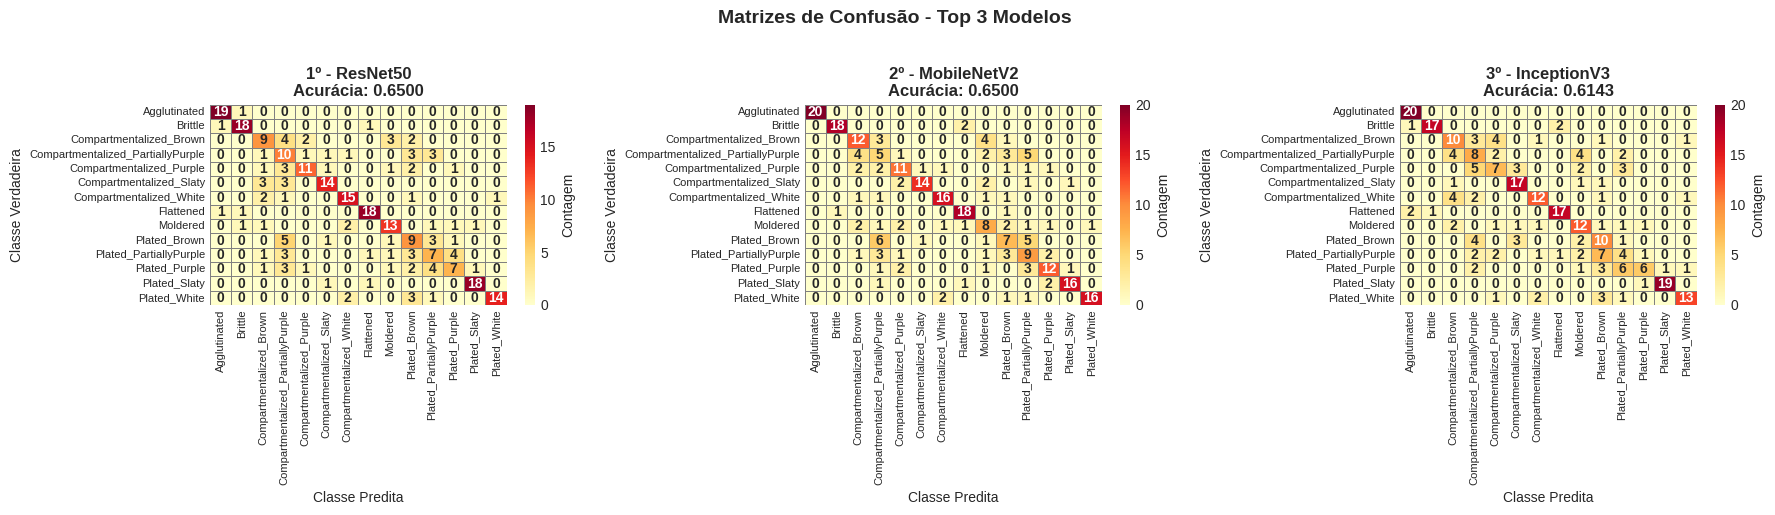

 Matrizes de confusão salvas: confusion_matrices_top3.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, model in enumerate(top_3):
    cm = model['Confusion_Matrix']

    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
                xticklabels=list(idx_to_class.values()),
                yticklabels=list(idx_to_class.values()),
                ax=axes[idx], cbar_kws={'label': 'Contagem'},
                linewidths=0.5, linecolor='gray',
                annot_kws={'size': 10, 'weight': 'bold'})

    axes[idx].set_title(f"{idx+1}º - {model['CNN']}\nAcurácia: {model['Test_Accuracy']:.4f}",
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Classe Predita', fontsize=10)
    axes[idx].set_ylabel('Classe Verdadeira', fontsize=10)
    axes[idx].tick_params(axis='both', labelsize=8)

plt.suptitle('Matrizes de Confusão - Top 3 Modelos', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices_top3.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Matrizes de confusão salvas: confusion_matrices_top3.png")

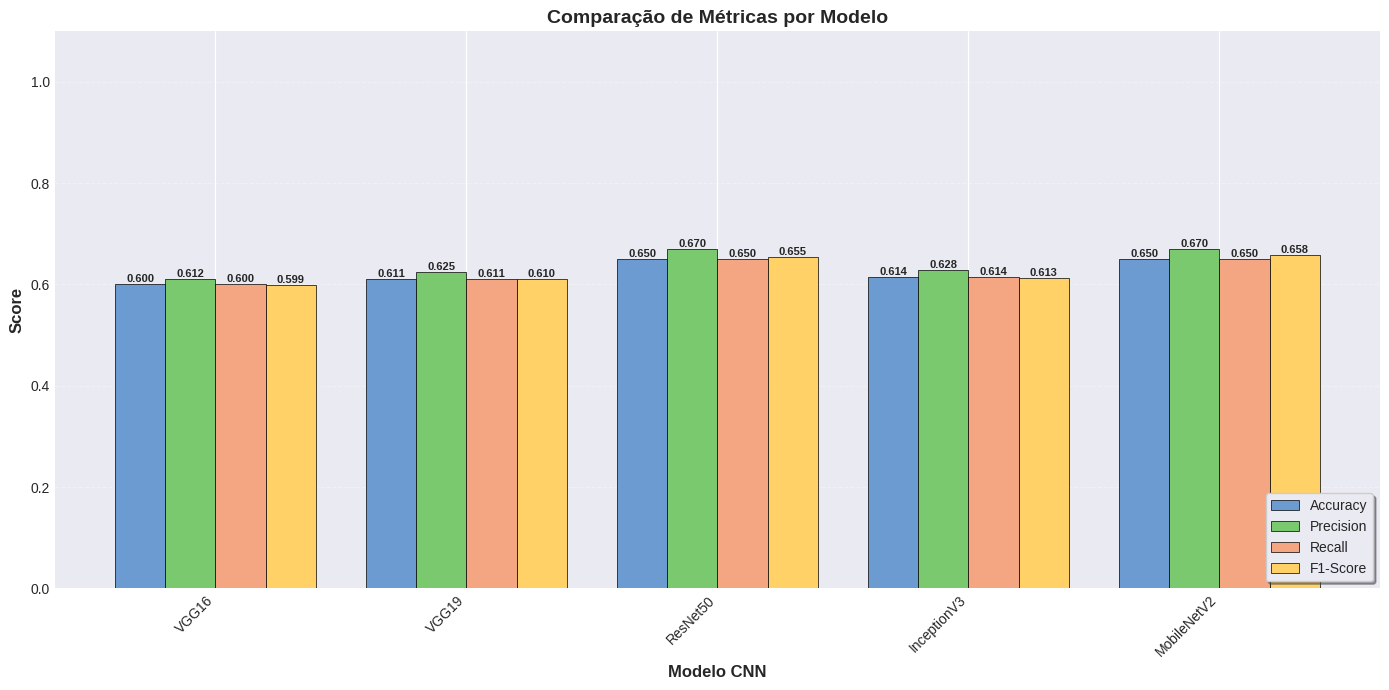

Comparação de métricas salva: metrics_comparison.png


In [21]:
metrics_comparison = pd.DataFrame([{
    'Model': r['CNN'],
    'Accuracy': r['Test_Accuracy'],
    'Precision': r['Test_Precision'],
    'Recall': r['Test_Recall'],
    'F1-Score': r['Test_F1']
} for r in results])

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(metrics_comparison))
width = 0.2

colors = {
    'Accuracy': '#6C9BD1',
    'Precision': '#7BC96F',
    'Recall': '#F4A582',
    'F1-Score': '#FFD166'
}

bars1 = ax.bar(x - 1.5*width, metrics_comparison['Accuracy'], width,
               label='Accuracy', color=colors['Accuracy'], edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x - 0.5*width, metrics_comparison['Precision'], width,
               label='Precision', color=colors['Precision'], edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + 0.5*width, metrics_comparison['Recall'], width,
               label='Recall', color=colors['Recall'], edgecolor='black', linewidth=0.5)
bars4 = ax.bar(x + 1.5*width, metrics_comparison['F1-Score'], width,
               label='F1-Score', color=colors['F1-Score'], edgecolor='black', linewidth=0.5)

def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

add_value_labels(bars1)
add_value_labels(bars2)
add_value_labels(bars3)
add_value_labels(bars4)

ax.set_xlabel('Modelo CNN', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Comparação de Métricas por Modelo', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_comparison['Model'], rotation=45, ha='right')
ax.legend(loc='lower right', frameon=True, shadow=True)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Comparação de métricas salva: metrics_comparison.png")

In [22]:
baseline = 0.8979
best_accuracy = top_3[0]['Test_Accuracy']

print("\n" + "="*70)
print("COMPARAÇÃO COM BASELINE DA LITERATURA")
print("="*70)
print(f"\nBaseline (Malcher and Guedes, 2022): {baseline:.4f} ({baseline*100:.2f}%)")
print(f"Melhor Resultado Obtido ({top_3[0]['CNN']}): {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print("\n" + "-"*70)

if best_accuracy > baseline:
    improvement = (best_accuracy - baseline) * 100
    print(f"BASELINE SUPERADO!")
    print(f"Ganho absoluto: +{improvement:.2f} pontos percentuais")
    print(f"Ganho relativo: +{(improvement/baseline*100):.2f}%")
else:
    difference = (baseline - best_accuracy) * 100
    print(f"Baseline não superado")
    print(f"Diferença: -{difference:.2f} pontos percentuais")

print("="*70)
print(f"\nRELATÓRIO DE CLASSIFICAÇÃO DETALHADO - {top_3[0]['CNN']}")
print("="*70)
print(classification_report(y_test, top_3[0]['y_pred'],
                          target_names=list(idx_to_class.values()),
                          digits=4))
print("="*70)


COMPARAÇÃO COM BASELINE DA LITERATURA

Baseline (Malcher and Guedes, 2022): 0.8979 (89.79%)
Melhor Resultado Obtido (ResNet50): 0.6500 (65.00%)

----------------------------------------------------------------------
Baseline não superado
Diferença: -24.79 pontos percentuais

RELATÓRIO DE CLASSIFICAÇÃO DETALHADO - ResNet50
                                   precision    recall  f1-score   support

                     Agglutinated     0.9048    0.9500    0.9268        20
                          Brittle     0.8571    0.9000    0.8780        20
          Compartmentalized_Brown     0.4737    0.4500    0.4615        20
Compartmentalized_PartiallyPurple     0.3125    0.5000    0.3846        20
         Compartmentalized_Purple     0.7333    0.5500    0.6286        20
          Compartmentalized_Slaty     0.7778    0.7000    0.7368        20
          Compartmentalized_White     0.7500    0.7500    0.7500        20
                        Flattened     0.8571    0.9000    0.8780        20